## **3. Model Evaluation**

This notebook loads the saved best model and evaluates it on the held-out test set.
It also creates:
- Classification report
- Confusion matrix
- ROC curve
- Precision-recall curve
- Error analysis sample

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc,
    f1_score,
    precision_score,
    recall_score
)

ARTIFACT_DIR = Path("artifacts")
MODEL_DIR = Path("model_store")
REPORT_DIR = Path("reports")
REPORT_DIR.mkdir(exist_ok=True)

test_df = pd.read_csv(ARTIFACT_DIR / "test_prepared.csv")
model = joblib.load(MODEL_DIR / "best_disaster_tweet_model.joblib")

feature_cols = ["clean_text", "text_length_chars", "word_count", "has_hashtag", "has_mention", "has_url"]
X_test = test_df[feature_cols]
y_test = test_df["target"]

preds = model.predict(X_test)

In [2]:
print("Accuracy :", round(accuracy_score(y_test, preds), 4))
print("Precision:", round(precision_score(y_test, preds), 4))
print("Recall   :", round(recall_score(y_test, preds), 4))
print("F1 Score :", round(f1_score(y_test, preds), 4))

Accuracy : 0.7997
Precision: 0.7672
Recall   : 0.7661
F1 Score : 0.7666


In [3]:
report = classification_report(y_test, preds, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
0,0.824138,0.825086,0.824612,869.000000
1,0.767228,0.766055,0.766641,654.000000
accuracy,0.799737,0.799737,0.799737,0.799737
macro avg,0.795683,0.795571,0.795627,1523.000000
weighted avg,0.799700,0.799737,0.799718,1523.000000


In [4]:
report_df.to_csv(REPORT_DIR / "classification_report.csv", index=True)
print("Saved report to reports/classification_report.csv")

Saved report to reports/classification_report.csv


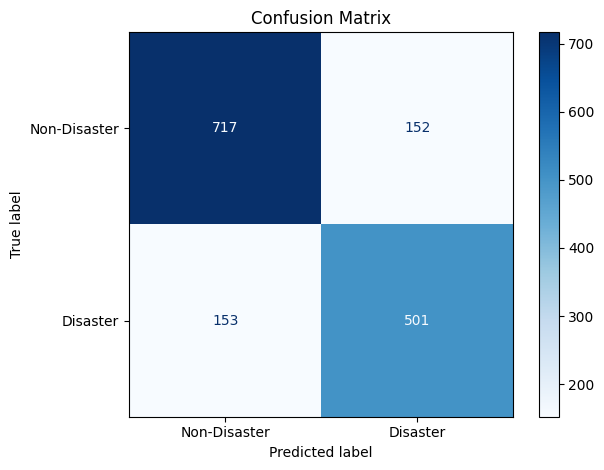

In [5]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Disaster", "Disaster"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## **ROC and Precision-Recall curves**

Some classifiers expose `predict_proba`, others expose `decision_function`.
The helper below handles both cases.

In [6]:
def get_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    elif hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    else:
        raise AttributeError("Model does not provide probability-like scores.")

scores = get_scores(model, X_test)

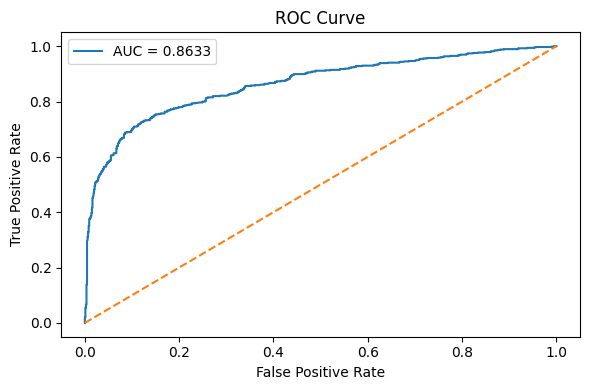

In [7]:
fpr, tpr, _ = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

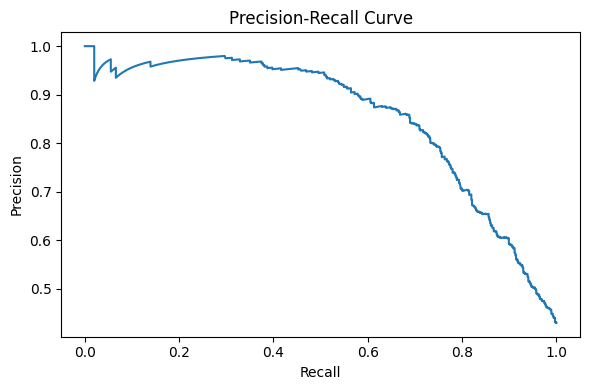

In [8]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, scores)

plt.figure(figsize=(6,4))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

# **Simple error analysis**


In [9]:
error_df = test_df.copy()
error_df["prediction"] = preds
error_df["correct"] = (error_df["target"] == error_df["prediction"]).astype(int)

misclassified = error_df[error_df["correct"] == 0][["text", "clean_text", "target", "prediction"]].head(20)
misclassified

,text,clean_text,target,prediction
0,@TheEconomist Step one: get that mass murderer...,step one get that mass murderer s portrait off...,0,1
5,Hollywood Movie About Trapped Miners Released ...,hollywood movie about trapped miners released ...,1,0
7,I can't drown my demons they know how to swim,i can t drown my demons they know how to swim,1,0
10,@nagel_ashley @Vicken52 @BasedLaRock @goonc1ty...,rip the world its burning,0,1
13,@XHNews We need these plants in the pacific du...,we need these plants in the pacific during the...,1,0
14,if firefighters acted like cops they'd drive a...,if firefighters acted like cops they d drive a...,0,1
20,Ignition Knock (Detonation) Sensor-Senso Stand...,ignition knock detonation sensor senso standar...,0,1
24,@POTUS Maybe we should call Israel and tell th...,maybe we should call israel and tell them we r...,0,1
27,I agree with certain cultural appropriation th...,i agree with certain cultural appropriation th...,1,0
29,The Dress Memes Have Officially Exploded On Th...,the dress memes have officially exploded on th...,1,0


In [10]:
misclassified.to_csv(REPORT_DIR / "misclassified_examples.csv", index=False)
print("Saved sample errors to reports/misclassified_examples.csv")

Saved sample errors to reports/misclassified_examples.csv


## Interpretation guide

I Focus on these when writing conclusions:
- High **precision** means fewer false alarms
- High **recall** means fewer missed real disasters
- **F1-score** balances both
- Misclassified examples help identify sarcasm, ambiguity, slang, and metaphor usage